Is a SMILES
Loading molecule
Checking if 5 or less H-donors... HAS 1 H-DONORS
Checking if 10 or less H-acceptors... HAS 1 H-ACCEPTORS
Checking if molecular mass is 500 or less daltons... 46.069 DALTONS
Checking if computational partition coefficient is 5 or less... IS -0.0014000000000000123
4 out of 4 rules passed
Passed Lipinski's


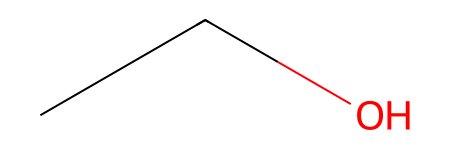

In [1]:
from rdkit import Chem
from rdkit.Chem import Lipinski as lip
from rdkit.Chem import Descriptors as des
from rdkit.Chem import Crippen
import requests
import os

#command for loading molecule from input
def load_molecule(user_input: str):
    mol_data = user_input.strip()

    #extracting from a weblink
    if mol_data.startswith('http'):
        print("Is a URL")
        try:
            response = requests.get(mol_data)
            response.raise_for_status()
            mol_data = response.text
        except Exception as e:
            print(f"Cannot read URL: {e}")
            return None

        mol = Chem.MolFromMolBlock(mol_data)
        if mol:
            print("Is a MOL/SDF")
            return mol
        else:
            print("URL is not a MOL/SDF")
            return None

    #extracting from local file
    elif os.path.exists(mol_data):
        print("Is a local file")
        try:
            with open(mol_data, 'r') as f:
                mol_block = f.read()
            mol = Chem.MolFromMolBlock(mol_block)
            if mol:
                print("Is a MOL/SDF")
                return mol
            else:
                print("Is not a MOL/SDF")
                return None
        except Exception as e:
            print(f"Cannot read local file: {e}")
            return None

    #extracting from rich text
    mol = Chem.MolFromMolBlock(mol_data)
    if mol:
        print("Is a MOL/SDF")
        return mol

    #extracting from SMILES
    mol = Chem.MolFromSmiles(mol_data)
    if mol:
        print("Is a SMILES")
        return mol

    print("Cannot read input")
    return None

#prompt for input
user_input = input("Input URL, local file path, or formatted text of MOL/SDF, or SMILES").strip()
mol = load_molecule(user_input)

#counter for Lipinski's rules
passed = 0
total_rules = 4

#checking each of Lipinski's rules and whether inputted molecule passes or not
if mol:
    print("Loading molecule")

    h_donors = lip.NumHDonors(mol)
    if h_donors <= 5:
        print(f"Checking if 5 or less H-donors... HAS {lip.NumHDonors(mol)} H-DONORS")
        passed += 1
    else:
        print(f"Checking if 5 or less H-donors... RULE VIOLATION: HAS {lip.NumHDonors(mol)} H-DONORS")

    h_acceptors = lip.NumHAcceptors(mol)
    if h_acceptors <= 10:
        print(f"Checking if 10 or less H-acceptors... HAS {lip.NumHAcceptors(mol)} H-ACCEPTORS")
        passed += 1
    else:
        print(f"Checking if 10 or less H-donors... RULE VIOLATION: HAS {lip.NumHAcceptors(mol)} H-ACCEPTORS")

    mass = des.MolWt(mol)
    if mass <= 500:
        print(f"Checking if molecular mass is 500 or less daltons... {des.MolWt(mol)} DALTONS")
        passed += 1
    else:
        print(f"Checking if molecular mass is 500 or less daltons... RULE VIOLATION: {des.MolWt(mol)} DALTONS")

    cLogP = Crippen.MolLogP(mol)
    if cLogP <= 5:
        print(f"Checking if computational partition coefficient is 5 or less... IS {Crippen.MolLogP(mol)}")
        passed += 1
    else:
        print(f"Checking if computational partition coefficient is 5 or less... RULE VIOLATION: IS {Crippen.MolLogP(mol)}")

    print(f"{passed} out of {total_rules} rules passed")

    if passed == total_rules:
        print("Passed Lipinski's")
    else:
        print("Failed Lipinski's")

else:
    print("Unable to load molecule")

#print molecular structure
mol

